# Predictive Modeling

This notebook tests whether current-season production, player context, and multi-year history can predict next-season NFL player value. The primary target is `next_value_score`, which is next season's position-adjusted total-EPA value score.

The model is meant for tiering and screening future value, not precise player ranking. Sports outcomes are noisy, so validation error and position-level diagnostics are central to the interpretation.


## Load Cleaned Data and Shared Pipeline Helpers

The modeling notebook uses the same value-score helper as Notebook 03. This keeps traded-player aggregation, minimum-game filtering, and standardized scoring consistent across the project.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")


def find_project_root(expected_file="data/processed/skill_player_seasons_2016_2025.csv"):
    """Find the repo root from common VS Code/Jupyter working directories."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / expected_file).exists():
            return candidate
    raise FileNotFoundError(
        "Could not find " + expected_file + " from working directory " + str(Path.cwd())
    )


project_root = find_project_root()
processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(project_root / "src"))
from prediction_report import (
    add_player_history_features,
    create_next_season_targets,
    create_player_season_value_scores,
)

skill_seasons_path = processed_dir / "skill_player_seasons_2016_2025.csv"
skill_player_team = pd.read_csv(skill_seasons_path)

value_scored = create_player_season_value_scores(skill_player_team)
player_season = add_player_history_features(value_scored)
player_season = create_next_season_targets(player_season)

target = "next_value_score"
modeling_df = player_season.dropna(subset=[target]).copy()

print("Raw player-season-team rows:", skill_player_team.shape)
print("Value-scored player-season rows:", value_scored.shape)
print("Rows with next-season target:", modeling_df.shape)

value_scored.head()


Raw player-season-team rows: (6082, 69)
Value-scored player-season rows: (4753, 81)
Rows with next-season target: (3086, 108)


,season,player_id,completions,attempts,passing_yards,passing_tds,passing_interceptions,sacks_suffered,sack_yards_lost,passing_air_yards,...,value_epa_total,value_epa_per_game,value_score,value_score_per_game,value_score_gap,value_score_total_epa,value_metric,team,position_season_rank,position_season_percentile
0,2016,00-0019596,291,432,3554,28,2,15,-87,3353,...,140.632333,11.719361,2.127596,2.264787,0.137191,2.127596,position_adjusted_total_epa,NE,3.0,0.960000
1,2016,00-0020337,0,0,0,0,0,0,0,0,...,37.947165,2.710512,1.390061,1.430829,0.040768,1.390061,position_adjusted_total_epa,BAL,18.0,0.903409
2,2016,00-0020531,471,673,5208,37,15,27,-184,4795,...,105.672159,6.604510,1.491620,1.172466,-0.319155,1.491620,position_adjusted_total_epa,NO,6.0,0.900000
4,2016,00-0021206,90,165,1100,6,6,18,-126,1649,...,-29.051473,-5.810295,-0.959196,-1.478825,-0.519629,-0.959196,position_adjusted_total_epa,CLE,45.0,0.120000
5,2016,00-0021429,364,597,4233,26,14,40,-281,5635,...,26.261320,1.750755,0.047023,0.135903,0.088880,0.047023,position_adjusted_total_epa,ARI,20.0,0.620000


## Modeling Unit and Target Check

Each row used for modeling should represent one player-season. Next-season targets are only assigned when the next qualifying row is exactly the following NFL season; this avoids linking across missed seasons.


In [2]:
print("Duplicate player-season rows:", player_season.duplicated(["season", "player_id"]).sum())
print("Target seasons represented:", sorted(modeling_df["next_season"].dropna().astype(int).unique()))

display(
    player_season[[
        "season", "player_display_name", "position", "team", "games_played",
        "value_score", "value_score_prev", "value_score_last2_avg",
        "value_score_last3_avg", "value_score_trend_2yr",
        "next_season", "next_value_score"
    ]].head(12)
)


Duplicate player-season rows: 0
Target seasons represented: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,season,player_display_name,position,team,games_played,value_score,value_score_prev,value_score_last2_avg,value_score_last3_avg,value_score_trend_2yr,next_season,next_value_score
0,2016,Tom Brady,QB,NE,12,2.127596,NaN,NaN,NaN,NaN,2017.0,2.242667
557,2017,Tom Brady,QB,NE,16,2.242667,2.127596,2.127596,2.127596,0.000000,2018.0,1.071892
1109,2018,Tom Brady,QB,NE,16,1.071892,2.242667,2.185131,2.185131,0.057535,2019.0,0.167967
1685,2019,Tom Brady,QB,NE,16,0.167967,1.071892,1.657280,1.814052,-0.585387,2020.0,1.301862
2257,2020,Tom Brady,QB,TB,16,1.301862,0.167967,0.619929,1.160842,-0.451963,2021.0,2.262979
2857,2021,Tom Brady,QB,TB,17,2.262979,1.301862,0.734915,0.847240,0.566948,2022.0,0.551216
3490,2022,Tom Brady,QB,TB,17,0.551216,2.262979,1.782421,1.244269,0.480558,NaN,NaN
1,2016,Steve Smith,WR,BAL,14,1.390061,NaN,NaN,NaN,NaN,NaN,NaN
2,2016,Drew Brees,QB,NO,16,1.491620,NaN,NaN,NaN,NaN,2017.0,1.686484
558,2017,Drew Brees,QB,NO,16,1.686484,1.491620,1.491620,1.491620,0.000000,2018.0,2.169809


## Feature Overlap Check

This heatmap shows why the notebook compares feature sets instead of throwing every variable into one model. Some features are alternative versions of the same signal, such as raw EPA and standardized EPA, or total EPA and EPA per game.

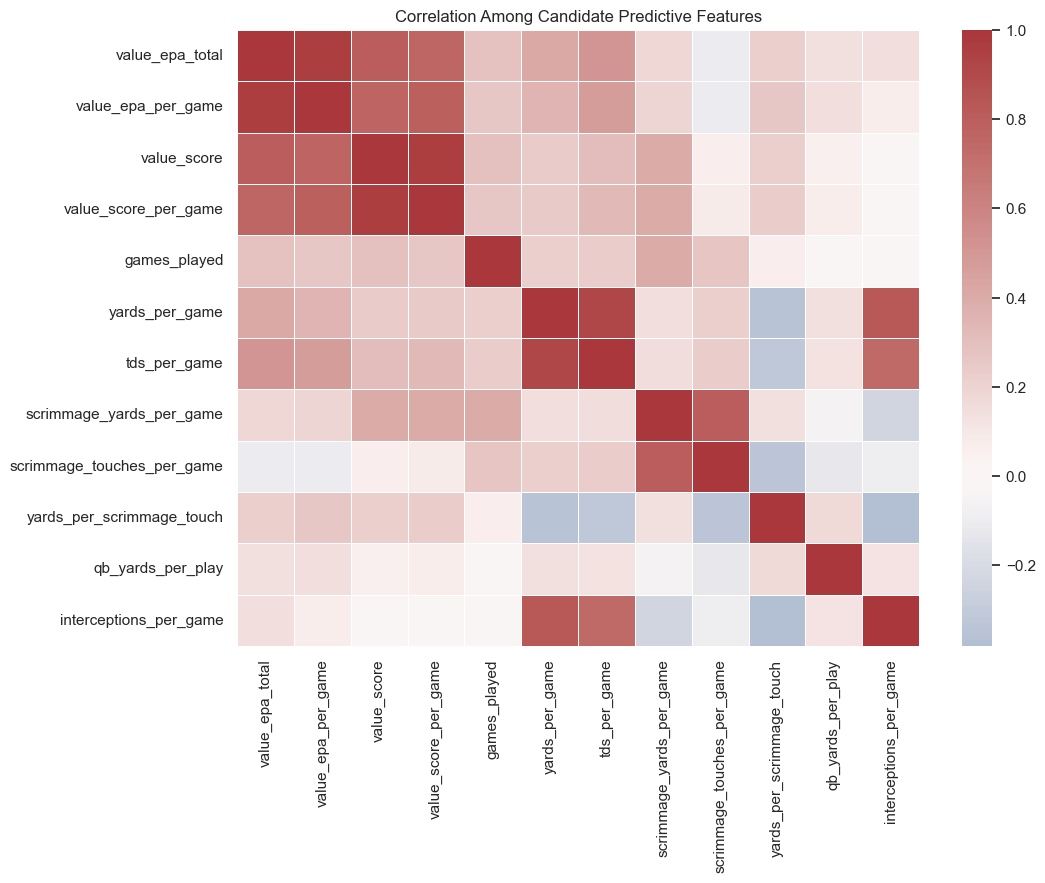

In [3]:
overlap_cols = [
    "value_epa_total", "value_epa_per_game", "value_score", "value_score_per_game",
    "games_played", "yards_per_game", "tds_per_game",
    "scrimmage_yards_per_game", "scrimmage_touches_per_game",
    "yards_per_scrimmage_touch", "qb_yards_per_play", "interceptions_per_game"
]

overlap_cols = [col for col in overlap_cols if col in modeling_df.columns]

plt.figure(figsize=(11, 8))
sns.heatmap(modeling_df[overlap_cols].corr(numeric_only=True), cmap="vlag", center=0, linewidths=0.5)
plt.title("Correlation Among Candidate Predictive Features")
plt.show()


## Train, Validation, and Test Split

The split is time-aware rather than random. This is important because the project is trying to predict future seasons from past information.

- Train: 2016-2022 seasons
- Validation: 2023 season
- Test: 2024 season

The 2024 test rows predict 2025 value, so 2025 is used as the target season but not as a feature season.


In [4]:
train_df = modeling_df[modeling_df["season"].between(2016, 2022)].copy()
valid_df = modeling_df[modeling_df["season"].eq(2023)].copy()
development_df = modeling_df[modeling_df["season"].between(2016, 2023)].copy()
test_df = modeling_df[modeling_df["season"].eq(2024)].copy()

target = "next_value_score"

print("Train:", train_df.shape, train_df["season"].min(), train_df["season"].max())
print("Validation:", valid_df.shape, valid_df["season"].unique())
print("Development for final fit:", development_df.shape, development_df["season"].min(), development_df["season"].max())
print("Test:", test_df.shape, test_df["season"].unique())


Train: (2367, 108) 2016 2022
Validation: (350, 108) [2023]
Development for final fit: (2717, 108) 2016 2023
Test: (369, 108) [2024]


## Define Feature Sets

Each feature set answers a slightly different modeling question.

- `profile`: player context and availability only.
- `raw_production`: current-season raw EPA and box-score production, without standardized duplicate metrics.
- `standardized_value`: current-season standardized value metrics only.
- `usage_efficiency`: role and efficiency signals without directly using the primary value score.
- `enhanced_history`: raw production plus prior-season value, rolling multi-year value, trend, and recent games played.

The enhanced-history feature set is the key upgrade in this version because it tests whether the model improves when it sees more than just the current season.


In [5]:
profile_features = [
    "position", "age", "years_exp", "draft_number", "games_played"
]

raw_production_features = [
    "position", "age", "years_exp", "draft_number", "games_played",
    "value_epa_total", "value_epa_per_game", "yards_per_game", "tds_per_game"
]

history_features = [
    "prior_qualifying_seasons", "value_score_prev", "value_score_last2_avg",
    "value_score_last3_avg", "value_score_trend_2yr", "value_epa_total_prev",
    "value_epa_per_game_prev", "games_played_prev", "games_played_last2_sum",
    "games_played_last3_avg", "yards_per_game_prev", "tds_per_game_prev"
]

feature_sets = {
    "profile": profile_features,
    "raw_production": raw_production_features,
    "standardized_value": [
        "position", "age", "years_exp", "draft_number", "games_played",
        "value_score", "value_score_per_game", "value_score_gap"
    ],
    "usage_efficiency": [
        "position", "age", "years_exp", "draft_number", "games_played",
        "attempts", "carries", "targets", "receptions",
        "scrimmage_touches_per_game", "yards_per_scrimmage_touch",
        "scrimmage_tds_per_game", "qb_yards_per_play", "qb_tds_per_game",
        "interceptions_per_game"
    ],
    "enhanced_history": raw_production_features + history_features,
}

feature_sets = {
    name: [col for col in cols if col in modeling_df.columns]
    for name, cols in feature_sets.items()
}

pd.DataFrame({
    "feature_set": list(feature_sets.keys()),
    "feature_count": [len(cols) for cols in feature_sets.values()],
    "features": [", ".join(cols) for cols in feature_sets.values()]
})


,feature_set,feature_count,features
0,profile,5,"position, age, years_exp, draft_number, games_..."
1,raw_production,9,"position, age, years_exp, draft_number, games_..."
2,standardized_value,8,"position, age, years_exp, draft_number, games_..."
3,usage_efficiency,15,"position, age, years_exp, draft_number, games_..."
4,enhanced_history,21,"position, age, years_exp, draft_number, games_..."


## Model Setup

The first model is a dummy baseline that always predicts the training-set average. The other models test whether player profile, production, and usage features add predictive signal.

Linear models are useful because they are interpretable, but correlated features can make coefficients unstable. Ridge regression helps with that by shrinking coefficients. Tree-based models can capture nonlinear patterns, but their feature importances should be interpreted carefully when features overlap.


In [6]:
models = {
    "dummy_mean": DummyRegressor(strategy="mean"),
    "linear_regression": LinearRegression(),
    "ridge": Ridge(alpha=10.0),
    "random_forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "gradient_boosting": GradientBoostingRegressor(random_state=42)
}


def make_pipeline(feature_cols, model):
    categorical_cols = [col for col in feature_cols if col == "position"]
    numeric_cols = [col for col in feature_cols if col not in categorical_cols]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])


def evaluate_predictions(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred)
    }


## Train and Compare Models

The results table reports validation and test metrics for each model-feature-set combination. Model selection should be based on validation performance; the test set is the final check on the selected approach.

In [7]:
results = []
fitted_models = {}

for feature_set_name, feature_cols in feature_sets.items():
    X_train = train_df[feature_cols]
    y_train = train_df[target]
    X_valid = valid_df[feature_cols]
    y_valid = valid_df[target]
    X_test = test_df[feature_cols]
    y_test = test_df[target]

    for model_name, model in models.items():
        if model_name == "dummy_mean" and feature_set_name != "profile":
            continue

        pipeline = make_pipeline(feature_cols, clone(model))
        pipeline.fit(X_train, y_train)

        valid_pred = pipeline.predict(X_valid)
        test_pred = pipeline.predict(X_test)

        valid_metrics = evaluate_predictions(y_valid, valid_pred)
        test_metrics = evaluate_predictions(y_test, test_pred)

        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "n_features": len(feature_cols),
            "valid_mae": valid_metrics["mae"],
            "valid_rmse": valid_metrics["rmse"],
            "valid_r2": valid_metrics["r2"],
            "test_mae": test_metrics["mae"],
            "test_rmse": test_metrics["rmse"],
            "test_r2": test_metrics["r2"]
        })

        fitted_models[(feature_set_name, model_name)] = pipeline

results_df = pd.DataFrame(results).sort_values(["valid_rmse", "test_rmse"])
results_df


,feature_set,model,n_features,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
19,enhanced_history,random_forest,21,0.681692,0.937649,0.213522,0.637930,0.922780,0.198401
7,raw_production,random_forest,9,0.671615,0.941110,0.207705,0.644994,0.945812,0.157887
20,enhanced_history,gradient_boosting,21,0.680522,0.949635,0.193286,0.632641,0.915394,0.211183
8,raw_production,gradient_boosting,9,0.679611,0.954588,0.184850,0.647233,0.929810,0.186141
16,usage_efficiency,gradient_boosting,15,0.689127,0.960445,0.174816,0.638694,0.942237,0.164241
18,enhanced_history,ridge,21,0.706443,0.961763,0.172549,0.648066,0.914356,0.212971
17,enhanced_history,linear_regression,21,0.704550,0.962686,0.170961,0.645127,0.912211,0.216658
11,standardized_value,random_forest,8,0.722015,0.965795,0.165598,0.651670,0.937312,0.172955
12,standardized_value,gradient_boosting,8,0.712694,0.967392,0.162835,0.657198,0.942521,0.163737
14,usage_efficiency,ridge,15,0.705093,0.968185,0.161462,0.648430,0.936879,0.173720


## Visualize Model Results

This chart compares validation RMSE across model and feature-set combinations. Lower values are better. If a more complex feature set does not beat a simpler one, that suggests the extra overlapping features may not be adding useful signal.

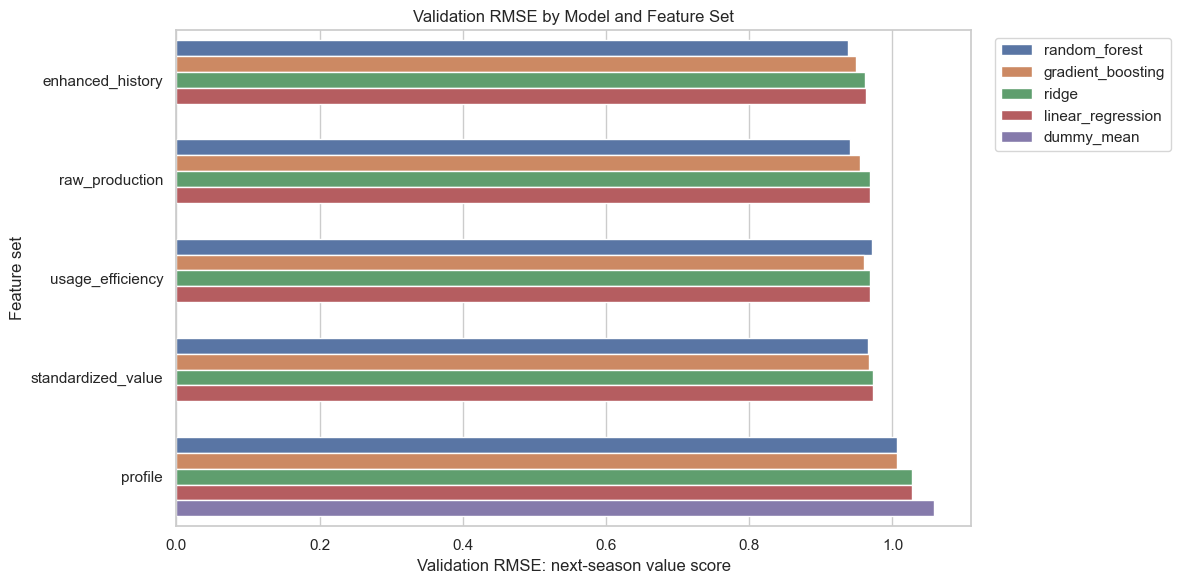

In [8]:
plt.figure(figsize=(12, 6))
plot_results = results_df.sort_values("valid_rmse")
sns.barplot(data=plot_results, x="valid_rmse", y="feature_set", hue="model")
plt.title("Validation RMSE by Model and Feature Set")
plt.xlabel("Validation RMSE: next-season value score")
plt.ylabel("Feature set")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Hyperparameter Tuning With Rolling Validation

The first model comparison used one validation season: 2023. That is useful, but it can make the results too dependent on one NFL season. This section tunes the main model families with rolling, football-time-aware validation folds.

Each fold trains on earlier seasons and validates on the next season. The 2024 test season stays untouched until after the best tuned setup is chosen.


In [9]:
rolling_validation_years = [2020, 2021, 2022, 2023]
rolling_folds = []

for valid_year in rolling_validation_years:
    fold_train = modeling_df[modeling_df["season"].lt(valid_year)].copy()
    fold_valid = modeling_df[modeling_df["season"].eq(valid_year)].copy()

    if not fold_train.empty and not fold_valid.empty:
        rolling_folds.append({
            "valid_year": valid_year,
            "train": fold_train,
            "valid": fold_valid
        })

pd.DataFrame({
    "valid_year": [fold["valid_year"] for fold in rolling_folds],
    "train_rows": [len(fold["train"]) for fold in rolling_folds],
    "valid_rows": [len(fold["valid"]) for fold in rolling_folds],
    "train_start": [fold["train"]["season"].min() for fold in rolling_folds],
    "train_end": [fold["train"]["season"].max() for fold in rolling_folds]
})


,valid_year,train_rows,valid_rows,train_start,train_end
0,2020,1313,352,2016,2019
1,2021,1665,360,2016,2020
2,2022,2025,342,2016,2021
3,2023,2367,350,2016,2022


In [10]:
tuning_models = {
    "ridge": Ridge(),
    "random_forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "gradient_boosting": GradientBoostingRegressor(random_state=42)
}

tuning_grids = {
    "ridge": {
        "alpha": [0.1, 1.0, 10.0, 50.0, 100.0]
    },
    "random_forest": {
        "n_estimators": [300],
        "max_depth": [5, 7, None],
        "min_samples_leaf": [10, 20],
        "max_features": [0.5, 0.75]
    },
    "gradient_boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.03, 0.05],
        "max_depth": [2, 3],
        "min_samples_leaf": [10, 20],
        "subsample": [0.8]
    }
}

# Tuning focuses on the production feature set currently used by the report and
# the enhanced-history version that adds prior seasons. This directly answers
# whether the multi-year feature upgrade helps after tuning.
tuning_feature_sets = [
    "raw_production",
    "enhanced_history",
]

tuning_records = []

for feature_set_name in tuning_feature_sets:
    feature_cols = feature_sets[feature_set_name]

    for model_name, base_model in tuning_models.items():
        for params in ParameterGrid(tuning_grids[model_name]):
            params_json = json.dumps(params, sort_keys=True)

            for fold in rolling_folds:
                fold_train = fold["train"]
                fold_valid = fold["valid"]

                model = clone(base_model).set_params(**params)
                pipeline = make_pipeline(feature_cols, model)
                pipeline.fit(fold_train[feature_cols], fold_train[target])

                valid_pred = pipeline.predict(fold_valid[feature_cols])
                valid_metrics = evaluate_predictions(fold_valid[target], valid_pred)

                tuning_records.append({
                    "feature_set": feature_set_name,
                    "model": model_name,
                    "params_json": params_json,
                    "valid_year": fold["valid_year"],
                    "valid_mae": valid_metrics["mae"],
                    "valid_rmse": valid_metrics["rmse"],
                    "valid_r2": valid_metrics["r2"]
                })

tuning_fold_results_df = pd.DataFrame(tuning_records)

tuning_results_df = (
    tuning_fold_results_df
    .groupby(["feature_set", "model", "params_json"], as_index=False)
    .agg(
        mean_valid_mae=("valid_mae", "mean"),
        mean_valid_rmse=("valid_rmse", "mean"),
        std_valid_rmse=("valid_rmse", "std"),
        mean_valid_r2=("valid_r2", "mean")
    )
    .sort_values(["mean_valid_rmse", "std_valid_rmse"])
)

tuning_results_df.head(15)


,feature_set,model,params_json,mean_valid_mae,mean_valid_rmse,std_valid_rmse,mean_valid_r2
25,enhanced_history,random_forest,"{""max_depth"": null, ""max_features"": 0.5, ""min_...",0.686323,0.929266,0.008870,0.230974
20,enhanced_history,random_forest,"{""max_depth"": 7, ""max_features"": 0.5, ""min_sam...",0.692018,0.930383,0.006322,0.229045
24,enhanced_history,random_forest,"{""max_depth"": null, ""max_features"": 0.5, ""min_...",0.688771,0.930595,0.003055,0.228627
22,enhanced_history,random_forest,"{""max_depth"": 7, ""max_features"": 0.75, ""min_sa...",0.691455,0.930980,0.004470,0.228029
21,enhanced_history,random_forest,"{""max_depth"": 7, ""max_features"": 0.5, ""min_sam...",0.690818,0.931108,0.010034,0.227940
23,enhanced_history,random_forest,"{""max_depth"": 7, ""max_features"": 0.75, ""min_sa...",0.690745,0.931847,0.009577,0.226707
16,enhanced_history,random_forest,"{""max_depth"": 5, ""max_features"": 0.5, ""min_sam...",0.698574,0.932027,0.009231,0.226396
27,enhanced_history,random_forest,"{""max_depth"": null, ""max_features"": 0.75, ""min...",0.688102,0.932041,0.009097,0.226373
4,enhanced_history,gradient_boosting,"{""learning_rate"": 0.03, ""max_depth"": 3, ""min_s...",0.698079,0.932828,0.008787,0.225049
1,enhanced_history,gradient_boosting,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_s...",0.696185,0.932844,0.010944,0.225066


## Tuned Candidate Comparison

The table above shows the exact parameter settings. This chart gives a quicker read on which tuned model families and feature sets are competing near the top.


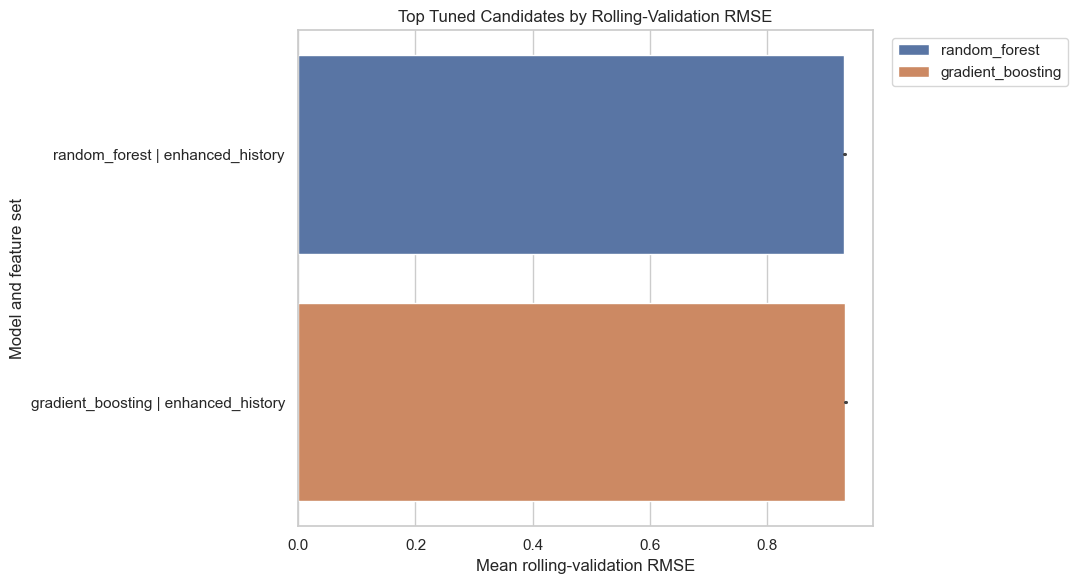

In [11]:
top_tuned = tuning_results_df.head(12).copy()
top_tuned["candidate"] = (
    top_tuned["model"] + " | " + top_tuned["feature_set"]
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=top_tuned,
    x="mean_valid_rmse",
    y="candidate",
    hue="model",
    dodge=False
)
plt.title("Top Tuned Candidates by Rolling-Validation RMSE")
plt.xlabel("Mean rolling-validation RMSE")
plt.ylabel("Model and feature set")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Tuned Model Selection

The selected tuned model is chosen by average rolling-validation RMSE. After selection, it is refit on all development seasons from 2016 through 2023, then evaluated once on the held-out 2024 test season.


In [12]:
best_baseline_row = results_df.iloc[0]
best_tuned_row = tuning_results_df.iloc[0]
best_tuned_params = json.loads(best_tuned_row["params_json"])

# Refit the best untuned baseline on the full development window so the test
# comparison uses the same training seasons as the tuned model.
baseline_key = (best_baseline_row["feature_set"], best_baseline_row["model"])
baseline_features = feature_sets[best_baseline_row["feature_set"]]
baseline_model = make_pipeline(baseline_features, clone(models[best_baseline_row["model"]]))
baseline_model.fit(development_df[baseline_features], development_df[target])
baseline_refit_pred = baseline_model.predict(test_df[baseline_features])
baseline_refit_metrics = evaluate_predictions(test_df[target], baseline_refit_pred)

best_key = (best_tuned_row["feature_set"], best_tuned_row["model"] + "_tuned")
best_features = feature_sets[best_tuned_row["feature_set"]]
best_model_template = clone(tuning_models[best_tuned_row["model"]]).set_params(**best_tuned_params)
best_model = make_pipeline(best_features, best_model_template)
best_model.fit(development_df[best_features], development_df[target])

tuned_test_pred = best_model.predict(test_df[best_features])
tuned_test_metrics = evaluate_predictions(test_df[target], tuned_test_pred)

selection_summary = pd.DataFrame([
    {
        "selection": "best_single_validation_baseline_refit",
        "feature_set": best_baseline_row["feature_set"],
        "model": best_baseline_row["model"],
        "single_validation_rmse": best_baseline_row["valid_rmse"],
        "rolling_validation_rmse": np.nan,
        "test_rmse": baseline_refit_metrics["rmse"],
        "test_r2": baseline_refit_metrics["r2"],
        "params": "default notebook settings"
    },
    {
        "selection": "best_rolling_validation_tuned_refit",
        "feature_set": best_tuned_row["feature_set"],
        "model": best_tuned_row["model"],
        "single_validation_rmse": np.nan,
        "rolling_validation_rmse": best_tuned_row["mean_valid_rmse"],
        "test_rmse": tuned_test_metrics["rmse"],
        "test_r2": tuned_test_metrics["r2"],
        "params": best_tuned_params
    }
])

print("Selected tuned model:", best_key)
print("Best tuned parameters:", best_tuned_params)
display(selection_summary)


Selected tuned model: ('enhanced_history', 'random_forest_tuned')
Best tuned parameters: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 20, 'n_estimators': 300}


,selection,feature_set,model,single_validation_rmse,rolling_validation_rmse,test_rmse,test_r2,params
0,best_single_validation_baseline_refit,enhanced_history,random_forest,0.937649,NaN,0.926117,0.192593,default notebook settings
1,best_rolling_validation_tuned_refit,enhanced_history,random_forest,NaN,0.929266,0.900743,0.236230,"{'max_depth': None, 'max_features': 0.5, 'min_..."


## Rolling Validation Error by Position

The pooled model uses `position` as a feature, but that does not guarantee it performs equally well for every position. This table checks the selected tuned model by position across the rolling-validation folds.

This is especially important for RBs and WRs because their production can decay faster with age, role changes, and injuries than QB production.


In [13]:
selected_rolling_predictions = []

for fold in rolling_folds:
    fold_train = fold["train"]
    fold_valid = fold["valid"]

    model = clone(tuning_models[best_tuned_row["model"]]).set_params(**best_tuned_params)
    pipeline = make_pipeline(best_features, model)
    pipeline.fit(fold_train[best_features], fold_train[target])

    fold_pred = pipeline.predict(fold_valid[best_features])
    fold_records = fold_valid[[
        "season", "player_id", "player_display_name", "position", target
    ]].copy()
    fold_records["predicted_next_value_score"] = fold_pred
    fold_records["residual"] = fold_records[target] - fold_records["predicted_next_value_score"]
    fold_records["abs_residual"] = fold_records["residual"].abs()
    fold_records["valid_year"] = fold["valid_year"]
    selected_rolling_predictions.append(fold_records)

selected_rolling_predictions = pd.concat(selected_rolling_predictions, ignore_index=True)

position_validation = (
    selected_rolling_predictions
    .groupby("position", as_index=False)
    .agg(
        validation_rows=("player_id", "count"),
        mean_actual_next_value=(target, "mean"),
        mean_predicted_next_value=("predicted_next_value_score", "mean"),
        bias=("residual", "mean"),
        mae=("abs_residual", "mean"),
        rmse=("residual", lambda s: np.sqrt(np.mean(np.square(s))))
    )
    .sort_values("position")
)

position_validation


,position,validation_rows,mean_actual_next_value,mean_predicted_next_value,bias,mae,rmse
0,QB,164,0.173568,0.194585,-0.021017,0.674543,0.873332
1,RB,358,-0.064634,-0.043047,-0.021587,0.754617,1.033500
2,TE,304,0.106793,0.008469,0.098324,0.661853,0.919006
3,WR,578,0.104768,0.186450,-0.081682,0.660241,0.880905


## Select Best Validation Model

The best model is selected by validation RMSE. Its test-set performance is then used as the best estimate of out-of-sample performance.

In [14]:
# The final selected model is assigned in the tuning section above.
# This cell keeps the original one-season baseline visible for comparison.
best_baseline_row = results_df.iloc[0]
best_baseline_key = (best_baseline_row["feature_set"], best_baseline_row["model"])

print("Best one-season validation baseline:", best_baseline_key)
display(best_baseline_row.to_frame().T)


Best one-season validation baseline: ('enhanced_history', 'random_forest')


,feature_set,model,n_features,valid_mae,valid_rmse,valid_r2,test_mae,test_rmse,test_r2
19,enhanced_history,random_forest,21,0.681692,0.937649,0.213522,0.63793,0.92278,0.198401


## Test-Set Predictions and Residuals

Residuals show where the model was too optimistic or too pessimistic. Positive residuals mean the player outperformed the model's prediction for next-season value. Negative residuals mean the player underperformed relative to the prediction.

In [15]:
test_predictions = test_df.copy()
test_predictions["predicted_next_value_score"] = best_model.predict(test_df[best_features])
test_predictions["prediction_residual"] = (
    test_predictions["next_value_score"] - test_predictions["predicted_next_value_score"]
)

display(
    test_predictions[[
        "season", "player_display_name", "position", "team", "games_played",
        "value_score", "next_season", "next_value_score",
        "predicted_next_value_score", "prediction_residual"
    ]]
    .sort_values("prediction_residual", ascending=False)
    .head(15)
)

display(
    test_predictions[[
        "season", "player_display_name", "position", "team", "games_played",
        "value_score", "next_season", "next_value_score",
        "predicted_next_value_score", "prediction_residual"
    ]]
    .sort_values("prediction_residual", ascending=True)
    .head(15)
)


,season,player_display_name,position,team,games_played,value_score,next_season,next_value_score,predicted_next_value_score,prediction_residual
5162,2024,Puka Nacua,WR,LA,11,2.112711,2025.0,6.057176,2.132337,3.924838
4890,2024,Jonathan Taylor,RB,IND,14,-1.799671,2025.0,2.762123,-0.675256,3.437379
5048,2024,Trey McBride,TE,ARI,16,2.861379,2025.0,4.422880,1.018259,3.404621
4999,2024,George Pickens,WR,PIT,14,0.697680,2025.0,4.135083,0.773423,3.361660
5093,2024,Jaxon Smith-Njigba,WR,SEA,17,1.812541,2025.0,4.239760,0.994778,3.244982
5242,2024,Drake Maye,QB,NE,13,-0.409516,2025.0,3.045983,-0.107997,3.153980
4705,2024,Stefon Diggs,WR,HOU,8,0.328638,2025.0,3.161962,0.819945,2.342017
4794,2024,Dalton Schultz,TE,HOU,17,-0.351508,2025.0,1.935656,-0.138996,2.074652
4900,2024,D'Andre Swift,RB,CHI,17,-1.884924,2025.0,1.556348,-0.442502,1.998850
5138,2024,Dalton Kincaid,TE,BUF,13,0.444331,2025.0,2.120280,0.214884,1.905396


,season,player_display_name,position,team,games_played,value_score,next_season,next_value_score,predicted_next_value_score,prediction_residual
4904,2024,Justin Jefferson,WR,MIN,17,2.585577,2025.0,-1.300782,1.965349,-3.266132
5184,2024,Bucky Irving,RB,TB,17,2.406612,2025.0,-1.913561,0.913841,-2.827401
4915,2024,Jerry Jeudy,WR,CLE,17,1.330244,2025.0,-2.131652,0.466933,-2.598585
4817,2024,Saquon Barkley,RB,PHI,16,3.247364,2025.0,-2.110151,0.457218,-2.567368
4771,2024,Alvin Kamara,RB,NO,14,-1.180157,2025.0,-3.081541,-0.712004,-2.369537
4841,2024,Tony Pollard,RB,TEN,16,-2.157913,2025.0,-2.490345,-0.203657,-2.286688
4745,2024,Taysom Hill,TE,NO,8,1.162549,2025.0,-1.612166,0.488807,-2.100973
4690,2024,Geno Smith,QB,SEA,17,0.070111,2025.0,-1.699952,0.071505,-1.771457
5256,2024,Ladd McConkey,WR,LAC,16,2.671992,2025.0,-0.182094,1.574397,-1.756491
4805,2024,Mark Andrews,TE,BAL,17,3.129847,2025.0,-0.043592,1.687225,-1.730817


## Actual vs Predicted Test Performance

A perfect model would place every point on the diagonal line. In real sports data, prediction is hard because injuries, role changes, team context, coaching, and player development can shift quickly from year to year.

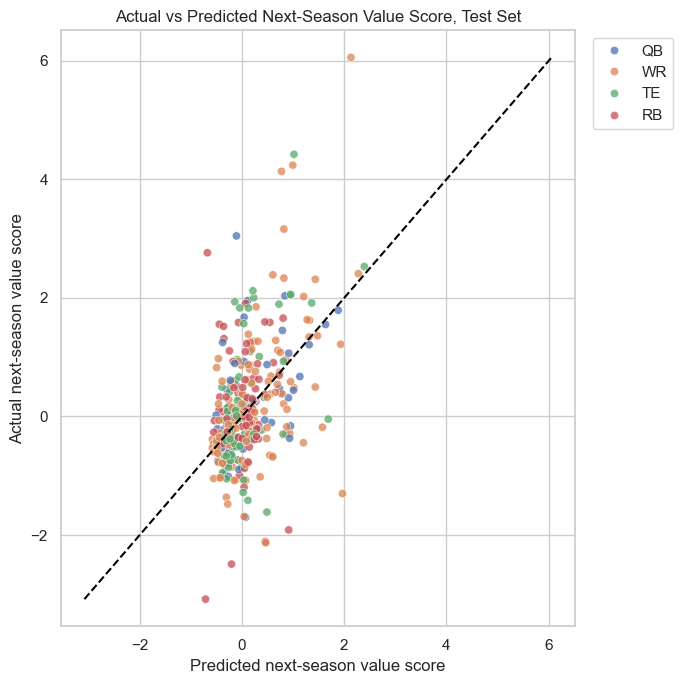

In [16]:
plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=test_predictions,
    x="predicted_next_value_score",
    y="next_value_score",
    hue="position",
    alpha=0.75
)
min_val = min(test_predictions["predicted_next_value_score"].min(), test_predictions["next_value_score"].min())
max_val = max(test_predictions["predicted_next_value_score"].max(), test_predictions["next_value_score"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--")
plt.title("Actual vs Predicted Next-Season Value Score, Test Set")
plt.xlabel("Predicted next-season value score")
plt.ylabel("Actual next-season value score")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Permutation Importance for the Selected Model

Permutation importance measures how much model performance gets worse when a feature is randomly shuffled. It is useful because it works with the full pipeline and original input columns.

Correlated features can still split importance, so this should be interpreted as a practical model diagnostic rather than a definitive causal ranking.

In [17]:
importance = permutation_importance(
    best_model,
    test_df[best_features],
    test_df[target],
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

importance_df = (
    pd.DataFrame({
        "feature": best_features,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)

importance_df


,feature,importance_mean,importance_std
5,value_epa_total,0.034336,0.011602
12,value_score_last3_avg,0.014399,0.003828
11,value_score_last2_avg,0.011914,0.003516
0,position,0.009482,0.001274
10,value_score_prev,0.005673,0.003006
3,draft_number,0.004593,0.001603
6,value_epa_per_game,0.003346,0.006775
7,yards_per_game,0.003132,0.002714
1,age,0.002564,0.002754
4,games_played,0.001988,0.001281


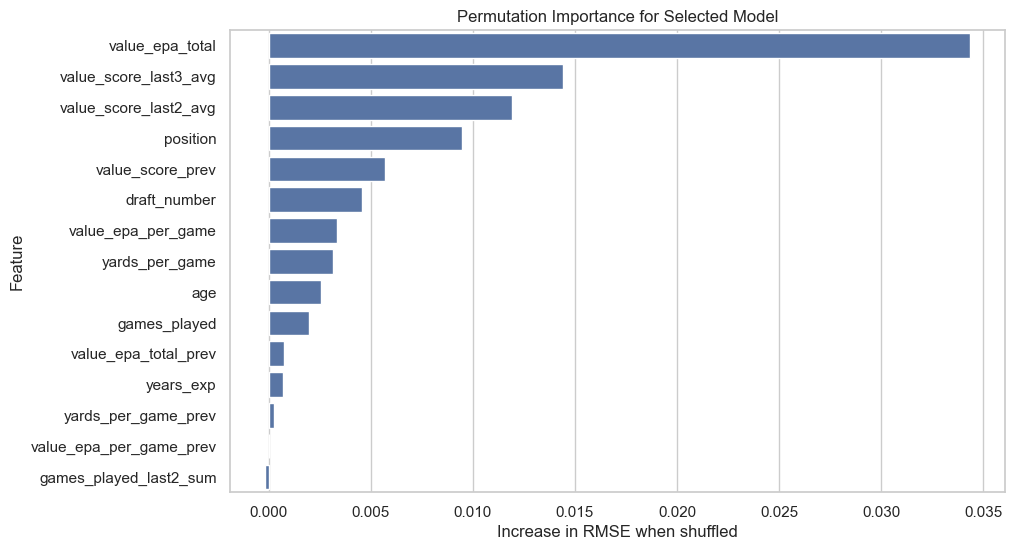

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance_mean", y="feature")
plt.title("Permutation Importance for Selected Model")
plt.xlabel("Increase in RMSE when shuffled")
plt.ylabel("Feature")
plt.show()


## Modeling Takeaways

This notebook is designed to answer four questions:

1. Can current-season information predict next-season value better than a simple baseline?
2. Which feature set is most useful without overloading the model with redundant versions of the same signal?
3. Do tuned model settings improve performance when they are chosen with time-aware validation instead of a random split?
4. Does the selected pooled model perform differently by position?

The enhanced-history feature set is the main modeling upgrade. It lets the model use prior-year value, rolling averages, trend, and recent games played instead of relying only on the current season. The position-level validation table is also important because a pooled model can hide weaker performance for specific positions, especially RBs.

The tuned section should still be interpreted carefully. Hyperparameter tuning can improve model fit, but it does not fix weak targets, missing context, survivorship bias, injuries, depth-chart changes, or noisy year-to-year NFL performance. In this project, tuning is useful because it makes the model comparison more defensible, not because it guarantees a dramatic accuracy jump.

The next notebook turns the selected enhanced-history model into the 2026 prediction report.
